# 23 Cross-Baseline Robustness

## Setup

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '23_cross_baseline_robustness'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_ORDER = ['MM', 'MW', 'WM', 'WW']
SLICE_ORDER = ['All→CS', 'CS→CS']
NEAR_PARITY_TOL = 0.01
UNIFIED_CORE_PATH = PROJECT_ROOT / 'outputs' / '13_unified_expected_observed_framework' / 'tables' / 'unified_observed_expected_all_baselines.csv'
R1_ALL_PATH = PROJECT_ROOT / 'outputs' / '10_baseline_r1_taxonomy_relevance' / 'tables' / 'baseline_r1_taxonomy_relevance_all_to_cs_summary.csv'
R1_CS_PATH = PROJECT_ROOT / 'outputs' / '10_baseline_r1_taxonomy_relevance' / 'tables' / 'baseline_r1_taxonomy_relevance_cs_to_cs_summary.csv'
GLM_PATH = PROJECT_ROOT / 'outputs' / '16_glm_models' / 'tables' / 'glm_representation_specific_oe_by_gender.csv'
RANDOM_DRAW_PATH = PROJECT_ROOT / 'outputs' / '18_randomized_drawing_baseline_weighted' / 'tables' / 'randomized_reference_drawing_oe_by_gender.csv'
NETWORK_RANDOM_PATH = PROJECT_ROOT / 'outputs' / '19_network_conditioned_edge_randomization' / 'tables' / 'network_conditioned_edge_randomization_oe_by_gender.csv'
BC_PRIOR_PATH = PROJECT_ROOT / 'outputs' / '20_bib_coupling_edge_randomization_prior_weighted' / 'tables' / 'bib_coupling_prior_weighted_randomization_oe_by_gender.csv'

## Standardization Functions

In [2]:
def clean_slice(value):
    s = str(value).strip()
    low = s.lower().replace(' ', '')
    if low in {'all→cs', 'all->cs', 'alltocs', 'all_to_cs'}:
        return 'All→CS'
    if low in {'cs→cs', 'cs->cs', 'cstocs', 'cs_to_cs'}:
        return 'CS→CS'
    return s

def clean_gender(value):
    return str(value).strip().upper()

def find_col(df, names):
    lower_map = {str(c).lower(): c for c in df.columns}
    for name in names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

def standardize_long(df, baseline_id, baseline_label, baseline_family, citation_slice=None, coverage_scope='full or analysis-defined', future_informed=False, gender_col=None, oe_col=None):
    x = df.copy()
    gender_col = gender_col or find_col(x, ['gender_cat', 'first_last_cat', 'gender', 'category'])
    oe_col = oe_col or find_col(x, ['oe_ratio', 'obs_exp_ratio', 'observed_expected_ratio', 'o_e'])
    if gender_col is None:
        unnamed = [c for c in x.columns if str(c).lower().startswith('unnamed')]
        if unnamed:
            gender_col = unnamed[0]
    if citation_slice is None:
        slice_col = find_col(x, ['citation_slice', 'slice'])
        slices = x[slice_col].map(clean_slice)
    else:
        slices = pd.Series([citation_slice] * len(x), index=x.index)
    out = pd.DataFrame({'baseline_id': baseline_id, 'baseline_label': baseline_label, 'baseline_family': baseline_family, 'citation_slice': slices, 'gender_cat': x[gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(x[oe_col], errors='coerce'), 'coverage_scope': coverage_scope, 'future_informed': bool(future_informed)})
    out = out[out['gender_cat'].isin(GENDER_ORDER) & out['citation_slice'].isin(SLICE_ORDER) & out['oe_ratio'].notna()].copy()
    return out

## D0–D3 and N1–N2

In [3]:
core_raw = pd.read_csv(UNIFIED_CORE_PATH)
print('Core columns:', core_raw.columns.tolist())
display(core_raw.head(20))
baseline_col = find_col(core_raw, ['baseline', 'baseline_name', 'model'])
gender_col = find_col(core_raw, ['gender_cat', 'first_last_cat', 'gender'])
oe_col = find_col(core_raw, ['oe_ratio', 'obs_exp_ratio'])
slice_col = find_col(core_raw, ['citation_slice', 'slice'])

def canonical_core_id(value):
    s = str(value).lower().replace('–', '-').replace('—', '-')
    if re.search('(^|[^a-z0-9])d0([^a-z0-9]|$)', s):
        return 'D0'
    if re.search('(^|[^a-z0-9])d1([^a-z0-9]|$)', s):
        return 'D1'
    if re.search('(^|[^a-z0-9])d2([^a-z0-9]|$)', s):
        return 'D2'
    if re.search('(^|[^a-z0-9])d3([^a-z0-9]|$)', s):
        return 'D3'
    if re.search('(^|[^a-z0-9])n1([^a-z0-9]|$)', s) or 'bibliographic' in s:
        return 'N1'
    if re.search('(^|[^a-z0-9])n2([^a-z0-9]|$)', s) or 'co-citation' in s or 'cocitation' in s:
        return 'N2'
    return None
CORE_LABELS = {'D0': 'D0: global paper share', 'D1': 'D1: decade', 'D2': 'D2: decade × subfield', 'D3': 'D3: decade × venue rank', 'N1': 'N1: bibliographic-coupling neighborhood', 'N2': 'N2: co-citation neighborhood'}
CORE_FAMILIES = {'D0': 'Direct structural', 'D1': 'Direct structural', 'D2': 'Direct structural', 'D3': 'Direct structural', 'N1': 'Network neighborhood', 'N2': 'Network neighborhood'}
core_raw['_canonical_id'] = core_raw[baseline_col].map(canonical_core_id)
core_use = core_raw[core_raw['_canonical_id'].isin(CORE_LABELS)].copy()
core_parts = []
for baseline_id in ['D0', 'D1', 'D2', 'D3', 'N1', 'N2']:
    q = core_use[core_use['_canonical_id'].eq(baseline_id)].copy()
    future = baseline_id == 'N2'
    coverage = 'network-covered papers' if baseline_id in {'N1', 'N2'} else 'full known-gender CS target population'
    out = pd.DataFrame({'baseline_id': baseline_id, 'baseline_label': CORE_LABELS[baseline_id], 'baseline_family': CORE_FAMILIES[baseline_id], 'citation_slice': q[slice_col].map(clean_slice), 'gender_cat': q[gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(q[oe_col], errors='coerce'), 'coverage_scope': coverage, 'future_informed': future})
    out = out[out['gender_cat'].isin(GENDER_ORDER) & out['citation_slice'].isin(SLICE_ORDER) & out['oe_ratio'].notna()]
    core_parts.append(out)
core = pd.concat(core_parts, ignore_index=True)
display(core)

Core columns: ['baseline', 'citation_slice', 'gender_cat', 'observed_citations', 'expected_citations', 'oe_ratio', 'pct_diff_from_expected', 'n_papers', 'n_edges', 'coverage_share', 'calibration_factor']


,baseline,citation_slice,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,n_papers,n_edges,coverage_share,calibration_factor
0,D0_global,All→CS,MM,6942653.0,6.350769e+06,1.093200,9.319900,790617.0,NaN,NaN,NaN
1,D0_global,All→CS,MW,641435.0,7.823745e+05,0.819900,-18.014300,97399.0,NaN,NaN,NaN
2,D0_global,All→CS,WM,812529.0,1.106549e+06,0.734300,-26.570900,137756.0,NaN,NaN,NaN
3,D0_global,All→CS,WW,289620.0,4.465444e+05,0.648600,-35.141900,55591.0,NaN,NaN,NaN
4,D1_decade,All→CS,MM,6942653.0,6.666726e+06,1.041389,4.138873,NaN,NaN,NaN,NaN
5,D1_decade,All→CS,MW,641435.0,6.837081e+05,0.938171,-6.182914,NaN,NaN,NaN,NaN
6,D1_decade,All→CS,WM,812529.0,9.190699e+05,0.884077,-11.592256,NaN,NaN,NaN,NaN
7,D1_decade,All→CS,WW,289620.0,4.167333e+05,0.694977,-30.502313,NaN,NaN,NaN,NaN
8,D2_decade_subfield,All→CS,MM,6942653.0,6.666918e+06,1.041359,4.135877,NaN,NaN,NaN,NaN
9,D2_decade_subfield,All→CS,MW,641435.0,6.856986e+05,0.935447,-6.455263,NaN,NaN,NaN,NaN


,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed
0,D0,D0: global paper share,Direct structural,All→CS,MM,1.093200,full known-gender CS target population,False
1,D0,D0: global paper share,Direct structural,All→CS,MW,0.819900,full known-gender CS target population,False
2,D0,D0: global paper share,Direct structural,All→CS,WM,0.734300,full known-gender CS target population,False
3,D0,D0: global paper share,Direct structural,All→CS,WW,0.648600,full known-gender CS target population,False
4,D0,D0: global paper share,Direct structural,CS→CS,MM,1.090900,full known-gender CS target population,False
5,D0,D0: global paper share,Direct structural,CS→CS,MW,0.836300,full known-gender CS target population,False
6,D0,D0: global paper share,Direct structural,CS→CS,WM,0.740100,full known-gender CS target population,False
7,D0,D0: global paper share,Direct structural,CS→CS,WW,0.638000,full known-gender CS target population,False
8,D1,D1: decade,Direct structural,All→CS,MM,1.041389,full known-gender CS target population,False
9,D1,D1: decade,Direct structural,All→CS,MW,0.938171,full known-gender CS target population,False


## Taxonomy-Weighted Baseline

In [4]:
def load_r1_taxonomy_weighted(path, citation_slice):
    x = pd.read_csv(path)
    unnamed = [c for c in x.columns if str(c).lower().startswith('unnamed')]
    if unnamed:
        first = unnamed[0]
        vals = set(x[first].astype(str).str.upper())
        if not vals.intersection(GENDER_ORDER):
            x = x.drop(columns=unnamed)
    gender_col = find_col(x, ['gender_cat', 'first_last_cat', 'gender', 'category'])
    if gender_col is None:
        first_col = x.columns[0]
        vals = set(x[first_col].astype(str).str.upper())
        if vals.intersection(GENDER_ORDER):
            gender_col = first_col
    tax_col = find_col(x, ['taxonomy_weighted', 'r1_taxonomy_weighted', 'taxonomy-weighted'])
    if tax_col is None:
        spec_col = find_col(x, ['specification', 'relevance_type', 'variant', 'analysis', 'baseline'])
        oe_col = find_col(x, ['oe_ratio', 'obs_exp_ratio'])
        if spec_col is not None and oe_col is not None:
            q = x[x[spec_col].astype(str).str.lower().str.contains('taxonomy')].copy()
            return standardize_long(q, baseline_id='R1_taxonomy_weighted', baseline_label='R1: taxonomy-weighted relevance', baseline_family='Topical relevance', citation_slice=citation_slice, coverage_scope='taxonomy-weighted citation edges', future_informed=False, gender_col=gender_col, oe_col=oe_col)
    out = pd.DataFrame({'baseline_id': 'R1_taxonomy_weighted', 'baseline_label': 'R1: taxonomy-weighted relevance', 'baseline_family': 'Topical relevance', 'citation_slice': citation_slice, 'gender_cat': x[gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(x[tax_col], errors='coerce'), 'coverage_scope': 'taxonomy-weighted citation edges', 'future_informed': False})
    return out[out['gender_cat'].isin(GENDER_ORDER) & out['oe_ratio'].notna()]
r1 = pd.concat([load_r1_taxonomy_weighted(R1_ALL_PATH, 'All→CS'), load_r1_taxonomy_weighted(R1_CS_PATH, 'CS→CS')], ignore_index=True)
display(r1)

,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed
0,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,All→CS,MM,1.037100,taxonomy-weighted citation edges,False
1,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,All→CS,MW,0.957729,taxonomy-weighted citation edges,False
2,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,All→CS,WM,0.893189,taxonomy-weighted citation edges,False
3,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,All→CS,WW,0.706712,taxonomy-weighted citation edges,False
4,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,CS→CS,MM,1.035286,taxonomy-weighted citation edges,False
5,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,CS→CS,MW,0.964821,taxonomy-weighted citation edges,False
6,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,CS→CS,WM,0.898981,taxonomy-weighted citation edges,False
7,R1_taxonomy_weighted,R1: taxonomy-weighted relevance,Topical relevance,CS→CS,WW,0.713076,taxonomy-weighted citation edges,False


## GLM M1–M5

In [5]:
glm_raw = pd.read_csv(GLM_PATH)
print('GLM columns:', glm_raw.columns.tolist())
display(glm_raw.head())
glm_gender_col = find_col(glm_raw, ['gender_cat', 'first_last_cat', 'gender'])
glm_oe_col = find_col(glm_raw, ['oe_ratio', 'obs_exp_ratio'])
glm_slice_col = find_col(glm_raw, ['citation_slice', 'slice'])
glm_model_col = find_col(glm_raw, ['model', 'model_name', 'specification'])

def canonical_glm(value):
    s = str(value).lower()
    for i in range(1, 6):
        if re.search(f'(^|[^a-z0-9])m{i}([^a-z0-9]|$)', s):
            return f'M{i}'
        if s.startswith(f'm{i}_'):
            return f'M{i}'
    return None
GLM_LABELS = {'M1': 'M1: structural GLM', 'M2': 'M2: direct-citation GLM', 'M3': 'M3: bibliographic-coupling GLM', 'M4': 'M4: co-citation GLM', 'M5': 'M5: combined-network GLM'}
glm_raw['_model_id'] = glm_raw[glm_model_col].map(canonical_glm)
glm_raw = glm_raw[glm_raw['_model_id'].isin(GLM_LABELS)].copy()
glm = pd.DataFrame({'baseline_id': glm_raw['_model_id'], 'baseline_label': glm_raw['_model_id'].map(GLM_LABELS), 'baseline_family': 'GLM', 'citation_slice': glm_raw[glm_slice_col].map(clean_slice), 'gender_cat': glm_raw[glm_gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(glm_raw[glm_oe_col], errors='coerce'), 'coverage_scope': 'full known-gender CS target population', 'future_informed': glm_raw['_model_id'].isin(['M4', 'M5'])})
glm = glm[glm['gender_cat'].isin(GENDER_ORDER) & glm['citation_slice'].isin(SLICE_ORDER) & glm['oe_ratio'].notna()].copy()
display(glm)

GLM columns: ['gender_cat', 'n_papers', 'observed_citations', 'expected_citations', 'oe_ratio', 'pct_diff_from_expected', 'model', 'citation_slice']


,gender_cat,n_papers,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,model,citation_slice
0,MM,790617,6942653.0,6.513816e+06,1.065835,6.583494,M1_structural,All→CS
1,MW,97399,641435.0,7.438709e+05,0.862293,-13.770655,M1_structural,All→CS
2,WM,137756,812529.0,1.032371e+06,0.787051,-21.294885,M1_structural,All→CS
3,WW,55591,289620.0,3.961785e+05,0.731034,-26.896590,M1_structural,All→CS
4,MM,790617,5601920.0,5.252989e+06,1.066425,6.642528,M1_structural,CS→CS


,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed
0,M1,M1: structural GLM,GLM,All→CS,MM,1.065835,full known-gender CS target population,False
1,M1,M1: structural GLM,GLM,All→CS,MW,0.862293,full known-gender CS target population,False
2,M1,M1: structural GLM,GLM,All→CS,WM,0.787051,full known-gender CS target population,False
3,M1,M1: structural GLM,GLM,All→CS,WW,0.731034,full known-gender CS target population,False
4,M1,M1: structural GLM,GLM,CS→CS,MM,1.066425,full known-gender CS target population,False
5,M1,M1: structural GLM,GLM,CS→CS,MW,0.873399,full known-gender CS target population,False
6,M1,M1: structural GLM,GLM,CS→CS,WM,0.785941,full known-gender CS target population,False
7,M1,M1: structural GLM,GLM,CS→CS,WW,0.714844,full known-gender CS target population,False
8,M2,M2: direct-citation GLM,GLM,All→CS,MM,1.066075,full known-gender CS target population,False
9,M2,M2: direct-citation GLM,GLM,All→CS,MW,0.861339,full known-gender CS target population,False


## Randomized Reference Drawing

In [6]:
draw_raw = pd.read_csv(RANDOM_DRAW_PATH)
print('Random drawing columns:', draw_raw.columns.tolist())
display(draw_raw.head())
draw_gender_col = find_col(draw_raw, ['gender_cat', 'first_last_cat', 'gender'])
draw_oe_col = find_col(draw_raw, ['oe_ratio', 'obs_exp_ratio'])
draw_slice_col = find_col(draw_raw, ['citation_slice', 'slice'])
elig_col = find_col(draw_raw, ['eligibility_rule', 'eligibility', 'temporal_eligibility'])
scheme_col = find_col(draw_raw, ['drawing_scheme', 'scheme', 'sampling_scheme', 'weighting'])

def clean_token(value):
    return str(value).strip().lower().replace('–', '_').replace('—', '_').replace('-', '_').replace(' ', '_')

def canonical_eligibility(value):
    s = clean_token(value)
    if '0' in s and '10' in s or 'age_0_10' in s:
        return 'age_0_10'
    if 'all_prior' in s or ('all' in s and 'prior' in s):
        return 'all_prior'
    return s

def canonical_scheme(value):
    s = clean_token(value)
    if 'uniform' in s:
        return 'uniform'
    if 'prior' in s or 'weighted' in s:
        return 'prior_weighted'
    return s
draw_raw['_elig'] = draw_raw[elig_col].map(canonical_eligibility)
draw_raw['_scheme'] = draw_raw[scheme_col].map(canonical_scheme)
DRAW_VARIANTS = {('age_0_10', 'uniform'): ('RD_0_10_uniform', 'Random draw: 0–10 years, uniform'), ('age_0_10', 'prior_weighted'): ('RD_0_10_prior', 'Random draw: 0–10 years, prior-weighted'), ('all_prior', 'uniform'): ('RD_all_prior_uniform', 'Random draw: all prior, uniform'), ('all_prior', 'prior_weighted'): ('RD_all_prior_prior', 'Random draw: all prior, prior-weighted')}
draw_parts = []
for key, (baseline_id, label) in DRAW_VARIANTS.items():
    q = draw_raw[draw_raw['_elig'].eq(key[0]) & draw_raw['_scheme'].eq(key[1])].copy()
    out = pd.DataFrame({'baseline_id': baseline_id, 'baseline_label': label, 'baseline_family': 'Randomized reference drawing', 'citation_slice': q[draw_slice_col].map(clean_slice), 'gender_cat': q[draw_gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(q[draw_oe_col], errors='coerce'), 'coverage_scope': 'all eligible known-gender citation edges', 'future_informed': False})
    draw_parts.append(out)
draw = pd.concat(draw_parts, ignore_index=True)
draw = draw[draw['gender_cat'].isin(GENDER_ORDER) & draw['citation_slice'].isin(SLICE_ORDER) & draw['oe_ratio'].notna()]
display(draw)

Random drawing columns: ['gender_cat', 'observed_citations', 'expected_citations', 'oe_ratio', 'pct_diff_from_expected', 'baseline', 'citation_slice', 'eligibility_rule', 'drawing_scheme', 'n_edges']


,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice,eligibility_rule,drawing_scheme,n_edges
0,MM,6942653.0,6.732932e+06,1.031148,3.114850,random_draw_age_0_10_prior_weighted,All→CS,age_0_10,prior_weighted,8686237
1,MW,641435.0,7.152295e+05,0.896824,-10.317602,random_draw_age_0_10_prior_weighted,All→CS,age_0_10,prior_weighted,8686237
2,WM,812529.0,9.112901e+05,0.891625,-10.837508,random_draw_age_0_10_prior_weighted,All→CS,age_0_10,prior_weighted,8686237
3,WW,289620.0,3.267850e+05,0.886271,-11.372931,random_draw_age_0_10_prior_weighted,All→CS,age_0_10,prior_weighted,8686237
4,MM,6942653.0,6.465237e+06,1.073844,7.384362,random_draw_age_0_10_uniform,All→CS,age_0_10,uniform,8686237


,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed
0,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,All→CS,MM,1.073844,all eligible known-gender citation edges,False
1,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,All→CS,MW,0.850343,all eligible known-gender citation edges,False
2,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,All→CS,WM,0.780203,all eligible known-gender citation edges,False
3,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,All→CS,WW,0.681070,all eligible known-gender citation edges,False
4,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,CS→CS,MM,1.068573,all eligible known-gender citation edges,False
5,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,CS→CS,MW,0.874123,all eligible known-gender citation edges,False
6,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,CS→CS,WM,0.794839,all eligible known-gender citation edges,False
7,RD_0_10_uniform,"Random draw: 0–10 years, uniform",Randomized reference drawing,CS→CS,WW,0.672106,all eligible known-gender citation edges,False
8,RD_0_10_prior,"Random draw: 0–10 years, prior-weighted",Randomized reference drawing,All→CS,MM,1.031148,all eligible known-gender citation edges,False
9,RD_0_10_prior,"Random draw: 0–10 years, prior-weighted",Randomized reference drawing,All→CS,MW,0.896824,all eligible known-gender citation edges,False


## Network-Conditioned Randomization

In [7]:
network_raw = pd.read_csv(NETWORK_RANDOM_PATH)
bc_prior_raw = pd.read_csv(BC_PRIOR_PATH)
print('Network randomization columns:', network_raw.columns.tolist())
print('BC prior sensitivity columns:', bc_prior_raw.columns.tolist())
net_gender_col = find_col(network_raw, ['gender_cat', 'first_last_cat', 'gender'])
net_oe_col = find_col(network_raw, ['oe_ratio', 'obs_exp_ratio'])
net_slice_col = find_col(network_raw, ['citation_slice', 'slice'])
net_baseline_col = find_col(network_raw, ['baseline', 'network', 'representation'])

def canonical_network_randomization(value):
    s = str(value).lower()
    if 'bibliographic' in s or re.search('(^|[^a-z])bc([^a-z]|$)', s):
        return 'NR_BC'
    if 'co-citation' in s or 'cocitation' in s or re.search('(^|[^a-z])co([^a-z]|$)', s):
        return 'NR_CO'
    return None
NETWORK_RANDOM_LABELS = {'NR_BC': 'Network randomization: bibliographic coupling', 'NR_CO': 'Network randomization: co-citation'}
network_raw['_network_id'] = network_raw[net_baseline_col].map(canonical_network_randomization)
network_raw = network_raw[network_raw['_network_id'].isin(NETWORK_RANDOM_LABELS)].copy()
network_random = pd.DataFrame({'baseline_id': network_raw['_network_id'], 'baseline_label': network_raw['_network_id'].map(NETWORK_RANDOM_LABELS), 'baseline_family': 'Network-conditioned randomization', 'citation_slice': network_raw[net_slice_col].map(clean_slice), 'gender_cat': network_raw[net_gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(network_raw[net_oe_col], errors='coerce'), 'coverage_scope': 'replaceable citation edges only', 'future_informed': network_raw['_network_id'].eq('NR_CO')})
network_random = network_random[network_random['gender_cat'].isin(GENDER_ORDER) & network_random['citation_slice'].isin(SLICE_ORDER) & network_random['oe_ratio'].notna()]
bc_gender_col = find_col(bc_prior_raw, ['gender_cat', 'first_last_cat', 'gender'])
bc_oe_col = find_col(bc_prior_raw, ['oe_ratio', 'obs_exp_ratio'])
bc_slice_col = find_col(bc_prior_raw, ['citation_slice', 'slice'])
bc_baseline_col = find_col(bc_prior_raw, ['baseline', 'variant', 'weighting'])
prior_mask = bc_prior_raw[bc_baseline_col].astype(str).str.lower().str.contains('prior')
bc_q = bc_prior_raw[prior_mask].copy()
if bc_q[bc_baseline_col].nunique() > 1:
    stronger_mask = bc_q[bc_baseline_col].astype(str).str.lower().str.contains('x_prior|prior_citation|network.*prior|prior.*citation', regex=True)
    if stronger_mask.any():
        bc_q = bc_q[stronger_mask].copy()
bc_prior = pd.DataFrame({'baseline_id': 'NR_BC_prior', 'baseline_label': 'BC randomization × prior citation', 'baseline_family': 'Network-conditioned randomization', 'citation_slice': bc_q[bc_slice_col].map(clean_slice), 'gender_cat': bc_q[bc_gender_col].map(clean_gender), 'oe_ratio': pd.to_numeric(bc_q[bc_oe_col], errors='coerce'), 'coverage_scope': 'same replaceable BC edge set', 'future_informed': False})
bc_prior = bc_prior[bc_prior['gender_cat'].isin(GENDER_ORDER) & bc_prior['citation_slice'].isin(SLICE_ORDER) & bc_prior['oe_ratio'].notna()].drop_duplicates(['baseline_id', 'citation_slice', 'gender_cat'])
display(network_random)
display(bc_prior)

Network randomization columns: ['gender_cat', 'observed_citations', 'expected_citations', 'oe_ratio', 'pct_diff_from_expected', 'baseline', 'citation_slice', 'replaceable_edges', 'edge_coverage', 'replaceable_targets', 'target_coverage']
BC prior sensitivity columns: ['baseline', 'citation_slice', 'gender_cat', 'observed_citations', 'expected_citations', 'replaceable_edges', 'oe_ratio', 'pct_diff_from_expected']


,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed
0,NR_BC,Network randomization: bibliographic coupling,Network-conditioned randomization,All→CS,MM,1.031252,replaceable citation edges only,False
1,NR_BC,Network randomization: bibliographic coupling,Network-conditioned randomization,All→CS,MW,0.926721,replaceable citation edges only,False
2,NR_BC,Network randomization: bibliographic coupling,Network-conditioned randomization,All→CS,WM,0.887275,replaceable citation edges only,False
3,NR_BC,Network randomization: bibliographic coupling,Network-conditioned randomization,All→CS,WW,0.832259,replaceable citation edges only,False
4,NR_CO,Network randomization: co-citation,Network-conditioned randomization,All→CS,MM,1.006167,replaceable citation edges only,True
5,NR_CO,Network randomization: co-citation,Network-conditioned randomization,All→CS,MW,0.999978,replaceable citation edges only,True
6,NR_CO,Network randomization: co-citation,Network-conditioned randomization,All→CS,WM,0.949292,replaceable citation edges only,True
7,NR_CO,Network randomization: co-citation,Network-conditioned randomization,All→CS,WW,0.982095,replaceable citation edges only,True
8,NR_BC,Network randomization: bibliographic coupling,Network-conditioned randomization,CS→CS,MM,1.029233,replaceable citation edges only,False
9,NR_BC,Network randomization: bibliographic coupling,Network-conditioned randomization,CS→CS,MW,0.933549,replaceable citation edges only,False


,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed
4,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,All→CS,MM,1.014375,same replaceable BC edge set,False
5,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,All→CS,MW,0.946559,same replaceable BC edge set,False
6,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,All→CS,WM,0.956821,same replaceable BC edge set,False
7,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,All→CS,WW,0.917218,same replaceable BC edge set,False
12,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,MM,1.013372,same replaceable BC edge set,False
13,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,MW,0.948191,same replaceable BC edge set,False
14,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,WM,0.966085,same replaceable BC edge set,False
15,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,WW,0.912591,same replaceable BC edge set,False


## Unified Cross-Baseline Table

In [8]:
unified = pd.concat([core, r1, glm, draw, network_random, bc_prior], ignore_index=True)
BASELINE_ORDER = ['D0', 'D1', 'D2', 'D3', 'R1_taxonomy_weighted', 'N1', 'N2', 'M1', 'M2', 'M3', 'M4', 'M5', 'RD_0_10_uniform', 'RD_0_10_prior', 'RD_all_prior_uniform', 'RD_all_prior_prior', 'NR_BC', 'NR_CO', 'NR_BC_prior']
missing_baselines = set(BASELINE_ORDER) - set(unified['baseline_id'])
unexpected_baselines = set(unified['baseline_id']) - set(BASELINE_ORDER)
dupes = unified.duplicated(['baseline_id', 'citation_slice', 'gender_cat'], keep=False)
if dupes.any():
    display(unified.loc[dupes, ['baseline_id', 'citation_slice', 'gender_cat', 'oe_ratio']].sort_values(['baseline_id', 'citation_slice', 'gender_cat']))
expected_rows = len(BASELINE_ORDER) * len(SLICE_ORDER) * len(GENDER_ORDER)
unified['baseline_id'] = pd.Categorical(unified['baseline_id'], categories=BASELINE_ORDER, ordered=True)
unified['citation_slice'] = pd.Categorical(unified['citation_slice'], categories=SLICE_ORDER, ordered=True)
unified['gender_cat'] = pd.Categorical(unified['gender_cat'], categories=GENDER_ORDER, ordered=True)
unified = unified.sort_values(['citation_slice', 'baseline_id', 'gender_cat']).reset_index(drop=True)
unified['deviation_from_parity'] = unified['oe_ratio'] - 1
unified['abs_deviation_from_parity'] = unified['deviation_from_parity'].abs()
unified['pct_diff_from_expected'] = 100 * unified['deviation_from_parity']
display(unified)

,baseline_id,baseline_label,baseline_family,citation_slice,gender_cat,oe_ratio,coverage_scope,future_informed,deviation_from_parity,abs_deviation_from_parity,pct_diff_from_expected
0,D0,D0: global paper share,Direct structural,All→CS,MM,1.093200,full known-gender CS target population,False,0.093200,0.093200,9.320000
1,D0,D0: global paper share,Direct structural,All→CS,MW,0.819900,full known-gender CS target population,False,-0.180100,0.180100,-18.010000
2,D0,D0: global paper share,Direct structural,All→CS,WM,0.734300,full known-gender CS target population,False,-0.265700,0.265700,-26.570000
3,D0,D0: global paper share,Direct structural,All→CS,WW,0.648600,full known-gender CS target population,False,-0.351400,0.351400,-35.140000
4,D1,D1: decade,Direct structural,All→CS,MM,1.041389,full known-gender CS target population,False,0.041389,0.041389,4.138873
...,...,...,...,...,...,...,...,...,...,...,...
147,NR_CO,Network randomization: co-citation,Network-conditioned randomization,CS→CS,WW,0.981094,replaceable citation edges only,True,-0.018906,0.018906,-1.890648
148,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,MM,1.013372,same replaceable BC edge set,False,0.013372,0.013372,1.337245
149,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,MW,0.948191,same replaceable BC edge set,False,-0.051809,0.051809,-5.180858
150,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,CS→CS,WM,0.966085,same replaceable BC edge set,False,-0.033915,0.033915,-3.391543


## Unified O/E Tables

In [9]:
def make_pivot(citation_slice):
    z = unified[unified['citation_slice'].eq(citation_slice)].copy()
    pivot = z.pivot(index='baseline_id', columns='gender_cat', values='oe_ratio').reindex(BASELINE_ORDER).reindex(columns=GENDER_ORDER)
    labels = z[['baseline_id', 'baseline_label']].drop_duplicates().set_index('baseline_id').reindex(BASELINE_ORDER)
    pivot.insert(0, 'baseline_label', labels['baseline_label'].values)
    return pivot
pivot_all = make_pivot('All→CS')
pivot_cs = make_pivot('CS→CS')
display(pivot_all)
display(pivot_cs)

gender_cat,baseline_label,MM,MW,WM,WW
baseline_id,,,,,
D0,D0: global paper share,1.093200,0.819900,0.734300,0.648600
D1,D1: decade,1.041389,0.938171,0.884077,0.694977
D2,D2: decade × subfield,1.041359,0.935447,0.876511,0.712268
D3,D3: decade × venue rank,1.030939,0.948746,0.907145,0.761855
R1_taxonomy_weighted,R1: taxonomy-weighted relevance,1.037100,0.957729,0.893189,0.706712
N1,N1: bibliographic-coupling neighborhood,1.049968,0.880605,0.827257,0.798771
N2,N2: co-citation neighborhood,1.011519,0.984655,0.918815,0.967353
M1,M1: structural GLM,1.065835,0.862293,0.787051,0.731034
M2,M2: direct-citation GLM,1.066075,0.861339,0.786324,0.731615


gender_cat,baseline_label,MM,MW,WM,WW
baseline_id,,,,,
D0,D0: global paper share,1.090900,0.836300,0.740100,0.638000
D1,D1: decade,1.038684,0.958330,0.893054,0.684191
D2,D2: decade × subfield,1.038606,0.954989,0.885550,0.702161
D3,D3: decade × venue rank,1.028322,0.967847,0.916377,0.751229
R1_taxonomy_weighted,R1: taxonomy-weighted relevance,1.035286,0.964821,0.898981,0.713076
N1,N1: bibliographic-coupling neighborhood,1.047122,0.891673,0.840432,0.795683
N2,N2: co-citation neighborhood,1.009550,0.992165,0.931473,0.969144
M1,M1: structural GLM,1.066425,0.873399,0.785941,0.714844
M2,M2: direct-citation GLM,1.066924,0.871447,0.784328,0.716251


## Cross-Baseline Heatmaps

Shared heatmap scale: 0.638 to 1.362 (centered at O/E = 1.000)


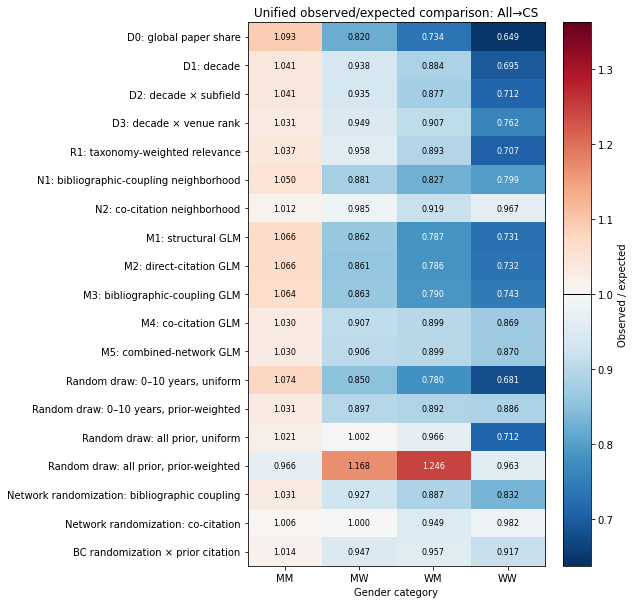

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\23_cross_baseline_robustness\figures\cross_baseline_oe_heatmap_all_to_cs.png


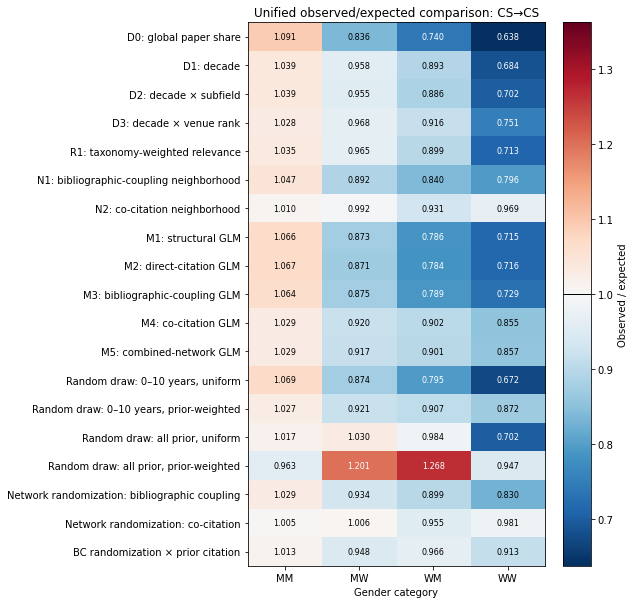

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\23_cross_baseline_robustness\figures\cross_baseline_oe_heatmap_cs_to_cs.png


In [10]:
GLOBAL_MAX_DEV = float(np.nanmax(np.abs(unified['oe_ratio'].astype(float) - 1.0)))
GLOBAL_VMIN = 1.0 - GLOBAL_MAX_DEV
GLOBAL_VMAX = 1.0 + GLOBAL_MAX_DEV
GLOBAL_NORM = TwoSlopeNorm(vmin=GLOBAL_VMIN, vcenter=1.0, vmax=GLOBAL_VMAX)
print('Shared heatmap scale:', f'{GLOBAL_VMIN:.3f} to {GLOBAL_VMAX:.3f}', '(centered at O/E = 1.000)')

def oe_heatmap(citation_slice, filename):
    z = unified[unified['citation_slice'].eq(citation_slice)].copy()
    mat = z.pivot(index='baseline_id', columns='gender_cat', values='oe_ratio').reindex(BASELINE_ORDER).reindex(columns=GENDER_ORDER)
    label_map = z[['baseline_id', 'baseline_label']].drop_duplicates().set_index('baseline_id')['baseline_label'].to_dict()
    row_labels = [label_map[b] for b in BASELINE_ORDER]
    arr = mat.to_numpy(dtype=float)
    fig_height = max(8.5, 0.43 * len(BASELINE_ORDER))
    fig, ax = plt.subplots(figsize=(8.8, fig_height))
    im = ax.imshow(arr, aspect='auto', norm=GLOBAL_NORM, cmap='RdBu_r')
    ax.set_xticks(np.arange(len(GENDER_ORDER)))
    ax.set_xticklabels(GENDER_ORDER)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Gender category')
    ax.set_ylabel('')
    ax.set_title(f'Unified observed/expected comparison: {citation_slice}')
    cmap = plt.get_cmap('RdBu_r')
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            rgba = cmap(GLOBAL_NORM(arr[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            text_color = 'black' if luminance > 0.58 else 'white'
            ax.text(j, i, f'{arr[i, j]:.3f}', ha='center', va='center', fontsize=8, color=text_color)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Observed / expected')
    cbar.ax.axhline(1.0, color='black', linewidth=1.0)
    plt.tight_layout()
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', path)
oe_heatmap('All→CS', 'cross_baseline_oe_heatmap_all_to_cs.png')
oe_heatmap('CS→CS', 'cross_baseline_oe_heatmap_cs_to_cs.png')

## Directional Stability

In [11]:
direction_rows = []
for sl in SLICE_ORDER:
    for gender in GENDER_ORDER:
        z = unified[unified['citation_slice'].eq(sl) & unified['gender_cat'].eq(gender)].copy()
        z = z.sort_values('oe_ratio')
        min_row = z.iloc[0]
        max_row = z.iloc[-1]
        vals = z['oe_ratio'].astype(float)
        n_below = int((vals < 1).sum())
        n_above = int((vals > 1).sum())
        n_equal = int(np.isclose(vals, 1.0, atol=1e-12).sum())
        n_near = int((np.abs(vals - 1) <= NEAR_PARITY_TOL).sum())
        direction_rows.append({'citation_slice': sl, 'gender_cat': gender, 'n_specifications': len(z), 'n_below_1': n_below, 'share_below_1': n_below / len(z), 'n_above_1': n_above, 'share_above_1': n_above / len(z), 'n_exactly_1': n_equal, 'n_within_1pct_of_parity': n_near, 'min_oe': min_row['oe_ratio'], 'min_baseline_id': str(min_row['baseline_id']), 'min_baseline_label': min_row['baseline_label'], 'q25_oe': vals.quantile(0.25), 'median_oe': vals.median(), 'mean_oe': vals.mean(), 'q75_oe': vals.quantile(0.75), 'max_oe': max_row['oe_ratio'], 'max_baseline_id': str(max_row['baseline_id']), 'max_baseline_label': max_row['baseline_label'], 'oe_range': vals.max() - vals.min()})
direction_summary = pd.DataFrame(direction_rows)
display(direction_summary)

,citation_slice,gender_cat,n_specifications,n_below_1,share_below_1,n_above_1,share_above_1,n_exactly_1,n_within_1pct_of_parity,min_oe,min_baseline_id,min_baseline_label,q25_oe,median_oe,mean_oe,q75_oe,max_oe,max_baseline_id,max_baseline_label,oe_range
0,All→CS,MM,19,1,0.052632,18,0.947368,0,1,0.966417,RD_all_prior_prior,"Random draw: all prior, prior-weighted",1.025517,1.031252,1.037133,1.057003,1.093200,D0,D0: global paper share,0.126783
1,All→CS,MW,19,17,0.894737,2,0.105263,0,2,0.819900,D0,D0: global paper share,0.872041,0.926721,0.929238,0.953237,1.167744,RD_all_prior_prior,"Random draw: all prior, prior-weighted",0.347844
2,All→CS,WM,19,18,0.947368,1,0.052632,0,0,0.734300,D0,D0: global paper share,0.808555,0.891625,0.888369,0.912980,1.245645,RD_all_prior_prior,"Random draw: all prior, prior-weighted",0.511345
3,All→CS,WW,19,19,1.000000,0,0.000000,0,0,0.648600,D0,D0: global paper share,0.712370,0.761855,0.800457,0.877983,0.982095,NR_CO,Network randomization: co-citation,0.333495
4,CS→CS,MM,19,1,0.052632,18,0.947368,0,2,0.962960,RD_all_prior_prior,"Random draw: all prior, prior-weighted",1.021954,1.029244,1.035126,1.055713,1.090900,D0,D0: global paper share,0.127940
5,CS→CS,MW,19,16,0.842105,3,0.157895,0,2,0.836300,D0,D0: global paper share,0.883228,0.933549,0.943997,0.966334,1.200596,RD_all_prior_prior,"Random draw: all prior, prior-weighted",0.364296
6,CS→CS,WM,19,18,0.947368,1,0.052632,0,0,0.740100,D0,D0: global paper share,0.817635,0.898981,0.896950,0.923925,1.268157,RD_all_prior_prior,"Random draw: all prior, prior-weighted",0.528057
7,CS→CS,WW,19,19,1.000000,0,0.000000,0,0,0.638000,D0,D0: global paper share,0.707618,0.751229,0.791685,0.864629,0.981094,NR_CO,Network randomization: co-citation,0.343094


## O/E Range Figures

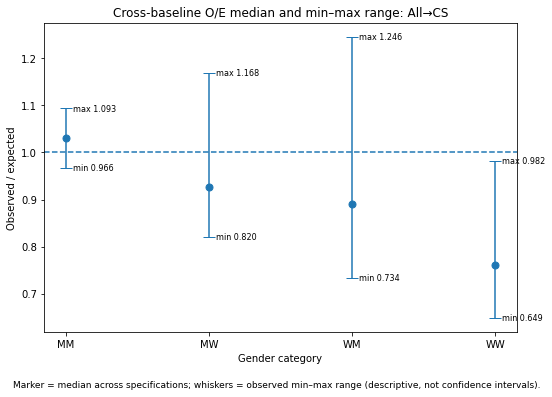

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\23_cross_baseline_robustness\figures\cross_baseline_oe_range_all_to_cs.png


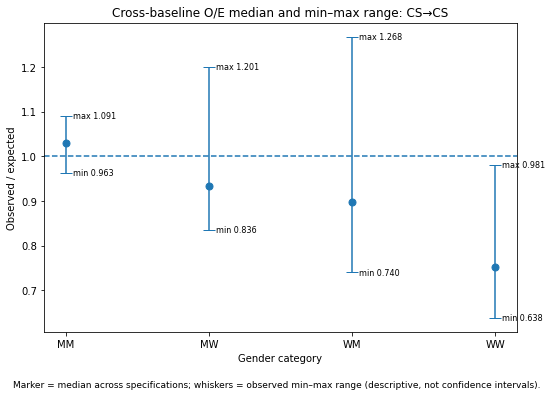

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\23_cross_baseline_robustness\figures\cross_baseline_oe_range_cs_to_cs.png


In [12]:
def range_plot(citation_slice, filename):
    z = direction_summary[direction_summary['citation_slice'].eq(citation_slice)].set_index('gender_cat').reindex(GENDER_ORDER)
    x = np.arange(len(GENDER_ORDER))
    med = z['median_oe'].to_numpy(dtype=float)
    min_oe = z['min_oe'].to_numpy(dtype=float)
    max_oe = z['max_oe'].to_numpy(dtype=float)
    lower = med - min_oe
    upper = max_oe - med
    fig, ax = plt.subplots(figsize=(7.8, 5.5))
    ax.errorbar(x, med, yerr=np.vstack([lower, upper]), fmt='o', capsize=6, markersize=7)
    ax.axhline(1, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(GENDER_ORDER)
    ax.set_xlabel('Gender category')
    ax.set_ylabel('Observed / expected')
    ax.set_title(f'Cross-baseline O/E median and min–max range: {citation_slice}')
    for i, (mn, md, mx) in enumerate(zip(min_oe, med, max_oe)):
        ax.annotate(f'max {mx:.3f}', (i, mx), xytext=(7, 0), textcoords='offset points', va='center', fontsize=8)
        ax.annotate(f'min {mn:.3f}', (i, mn), xytext=(7, 0), textcoords='offset points', va='center', fontsize=8)
    fig.text(0.5, 0.01, 'Marker = median across specifications; whiskers = observed min–max range (descriptive, not confidence intervals).', ha='center', fontsize=9)
    plt.tight_layout(rect=(0, 0.045, 1, 1))
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', path)
range_plot('All→CS', 'cross_baseline_oe_range_all_to_cs.png')
range_plot('CS→CS', 'cross_baseline_oe_range_cs_to_cs.png')

## Family-Level Directional Stability

In [13]:
family_summary = unified.groupby(['citation_slice', 'baseline_family', 'gender_cat'], observed=True).agg(n_variants=('oe_ratio', 'size'), min_oe=('oe_ratio', 'min'), median_oe=('oe_ratio', 'median'), max_oe=('oe_ratio', 'max'), mean_abs_deviation=('abs_deviation_from_parity', 'mean')).reset_index()
family_summary['all_below_1'] = family_summary['max_oe'] < 1
family_summary['all_above_1'] = family_summary['min_oe'] > 1
family_summary['crosses_parity'] = (family_summary['min_oe'] < 1) & (family_summary['max_oe'] > 1)
family_summary['contains_near_parity'] = (family_summary['min_oe'] <= 1 + NEAR_PARITY_TOL) & (family_summary['max_oe'] >= 1 - NEAR_PARITY_TOL)
display(family_summary)

,citation_slice,baseline_family,gender_cat,n_variants,min_oe,median_oe,max_oe,mean_abs_deviation,all_below_1,all_above_1,crosses_parity,contains_near_parity
0,All→CS,Direct structural,MM,4,1.030939,1.041374,1.093200,0.051722,False,True,False,False
1,All→CS,Direct structural,MW,4,0.819900,0.936809,0.948746,0.089434,True,False,False,False
2,All→CS,Direct structural,WM,4,0.734300,0.880294,0.907145,0.149492,True,False,False,False
3,All→CS,Direct structural,WW,4,0.648600,0.703622,0.761855,0.295575,True,False,False,False
4,All→CS,GLM,MM,5,1.029771,1.064039,1.066075,0.051119,False,True,False,False
5,All→CS,GLM,MW,5,0.861339,0.863477,0.907210,0.119945,True,False,False,False
6,All→CS,GLM,WM,5,0.786324,0.789854,0.899020,0.167777,True,False,False,False
7,All→CS,GLM,WW,5,0.731034,0.742872,0.869694,0.211253,True,False,False,False
8,All→CS,Network neighborhood,MM,2,1.011519,1.030744,1.049968,0.030744,False,True,False,False
9,All→CS,Network neighborhood,MW,2,0.880605,0.932630,0.984655,0.067370,True,False,False,False


## Citation-Slice Stability

In [14]:
slice_pivot = unified.pivot(index=['baseline_id', 'baseline_label', 'baseline_family', 'gender_cat'], columns='citation_slice', values='oe_ratio').reset_index()
slice_pivot['cs_minus_all'] = slice_pivot['CS→CS'] - slice_pivot['All→CS']
slice_pivot['abs_slice_difference'] = slice_pivot['cs_minus_all'].abs()
slice_difference_summary = slice_pivot.groupby('gender_cat', observed=True).agg(mean_abs_slice_difference=('abs_slice_difference', 'mean'), median_abs_slice_difference=('abs_slice_difference', 'median'), max_abs_slice_difference=('abs_slice_difference', 'max')).reindex(GENDER_ORDER).reset_index()
display(slice_pivot)
display(slice_difference_summary)

citation_slice,baseline_id,baseline_label,baseline_family,gender_cat,All→CS,CS→CS,cs_minus_all,abs_slice_difference
0,D0,D0: global paper share,Direct structural,MM,1.093200,1.090900,-0.002300,0.002300
1,D0,D0: global paper share,Direct structural,MW,0.819900,0.836300,0.016400,0.016400
2,D0,D0: global paper share,Direct structural,WM,0.734300,0.740100,0.005800,0.005800
3,D0,D0: global paper share,Direct structural,WW,0.648600,0.638000,-0.010600,0.010600
4,D1,D1: decade,Direct structural,MM,1.041389,1.038684,-0.002705,0.002705
...,...,...,...,...,...,...,...,...
71,NR_CO,Network randomization: co-citation,Network-conditioned randomization,WW,0.982095,0.981094,-0.001001,0.001001
72,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,MM,1.014375,1.013372,-0.001003,0.001003
73,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,MW,0.946559,0.948191,0.001632,0.001632
74,NR_BC_prior,BC randomization × prior citation,Network-conditioned randomization,WM,0.956821,0.966085,0.009264,0.009264


,gender_cat,mean_abs_slice_difference,median_abs_slice_difference,max_abs_slice_difference
0,MM,0.002187,0.002019,0.005271
1,MW,0.014760,0.011307,0.032852
2,WM,0.008983,0.009039,0.022512
3,WW,0.009630,0.010600,0.016202


## Evidence Summary by Gender Category

In [15]:
evidence_rows = []
for gender in GENDER_ORDER:
    for sl in SLICE_ORDER:
        d = direction_summary[direction_summary['citation_slice'].eq(sl) & direction_summary['gender_cat'].eq(gender)].iloc[0]
        fam = family_summary[family_summary['citation_slice'].eq(sl) & family_summary['gender_cat'].eq(gender)].copy()
        n_families = fam['baseline_family'].nunique()
        n_families_all_below = int(fam['all_below_1'].sum())
        n_families_all_above = int(fam['all_above_1'].sum())
        n_families_cross = int(fam['crosses_parity'].sum())
        evidence_rows.append({'citation_slice': sl, 'gender_cat': gender, 'n_specifications': int(d['n_specifications']), 'n_below_1': int(d['n_below_1']), 'n_above_1': int(d['n_above_1']), 'n_within_1pct_of_parity': int(d['n_within_1pct_of_parity']), 'min_oe': d['min_oe'], 'min_baseline': d['min_baseline_label'], 'median_oe': d['median_oe'], 'max_oe': d['max_oe'], 'max_baseline': d['max_baseline_label'], 'n_baseline_families': n_families, 'families_uniformly_below': n_families_all_below, 'families_uniformly_above': n_families_all_above, 'families_crossing_parity': n_families_cross})
evidence_summary = pd.DataFrame(evidence_rows)
evidence_summary = evidence_summary.merge(slice_difference_summary[['gender_cat', 'mean_abs_slice_difference', 'median_abs_slice_difference', 'max_abs_slice_difference']], on='gender_cat', how='left')
display(evidence_summary)

,citation_slice,gender_cat,n_specifications,n_below_1,n_above_1,n_within_1pct_of_parity,min_oe,min_baseline,median_oe,max_oe,max_baseline,n_baseline_families,families_uniformly_below,families_uniformly_above,families_crossing_parity,mean_abs_slice_difference,median_abs_slice_difference,max_abs_slice_difference
0,All→CS,MM,19,1,18,1,0.966417,"Random draw: all prior, prior-weighted",1.031252,1.093200,D0: global paper share,6,0,5,1,0.002187,0.002019,0.005271
1,CS→CS,MM,19,1,18,2,0.962960,"Random draw: all prior, prior-weighted",1.029244,1.090900,D0: global paper share,6,0,5,1,0.002187,0.002019,0.005271
2,All→CS,MW,19,17,2,2,0.819900,D0: global paper share,0.926721,1.167744,"Random draw: all prior, prior-weighted",6,5,0,1,0.014760,0.011307,0.032852
3,CS→CS,MW,19,16,3,2,0.836300,D0: global paper share,0.933549,1.200596,"Random draw: all prior, prior-weighted",6,4,0,2,0.014760,0.011307,0.032852
4,All→CS,WM,19,18,1,0,0.734300,D0: global paper share,0.891625,1.245645,"Random draw: all prior, prior-weighted",6,5,0,1,0.008983,0.009039,0.022512
5,CS→CS,WM,19,18,1,0,0.740100,D0: global paper share,0.898981,1.268157,"Random draw: all prior, prior-weighted",6,5,0,1,0.008983,0.009039,0.022512
6,All→CS,WW,19,19,0,0,0.648600,D0: global paper share,0.761855,0.982095,Network randomization: co-citation,6,6,0,0,0.009630,0.010600,0.016202
7,CS→CS,WW,19,19,0,0,0.638000,D0: global paper share,0.751229,0.981094,Network randomization: co-citation,6,6,0,0,0.009630,0.010600,0.016202


## Baseline-Family Magnitude Comparison

In [16]:
family_magnitude = unified.groupby(['citation_slice', 'baseline_family'], observed=True).agg(n_specification_gender_cells=('oe_ratio', 'size'), mean_abs_deviation_from_1=('abs_deviation_from_parity', 'mean'), median_abs_deviation_from_1=('abs_deviation_from_parity', 'median'), min_oe=('oe_ratio', 'min'), max_oe=('oe_ratio', 'max')).reset_index()
display(family_magnitude)

,citation_slice,baseline_family,n_specification_gender_cells,mean_abs_deviation_from_1,median_abs_deviation_from_1,min_oe,max_oe
0,All→CS,Direct structural,16,0.146556,0.104561,0.648600,1.093200
1,All→CS,GLM,20,0.137524,0.130893,0.731034,1.066075
2,All→CS,Network neighborhood,8,0.085504,0.065576,0.798771,1.049968
3,All→CS,Network-conditioned randomization,12,0.054465,0.046943,0.832259,1.031252
4,All→CS,Randomized reference drawing,16,0.121717,0.105776,0.681070,1.245645
5,All→CS,Topical relevance,4,0.119867,0.074541,0.706712,1.037100
6,CS→CS,Direct structural,16,0.141774,0.098923,0.638000,1.090900
7,CS→CS,GLM,20,0.138275,0.125909,0.714844,1.066924
8,CS→CS,Network neighborhood,8,0.079513,0.057825,0.795683,1.047122
9,CS→CS,Network-conditioned randomization,12,0.052333,0.039280,0.830115,1.029233


## Save Results

In [17]:
unified_save = unified.copy()
unified_save['baseline_id'] = unified_save['baseline_id'].astype(str)
unified_save['citation_slice'] = unified_save['citation_slice'].astype(str)
unified_save['gender_cat'] = unified_save['gender_cat'].astype(str)
unified_save.to_csv(TABLE_DIR / 'cross_baseline_unified_oe_long.csv', index=False)
pivot_all.to_csv(TABLE_DIR / 'cross_baseline_oe_pivot_all_to_cs.csv', index=True)
pivot_cs.to_csv(TABLE_DIR / 'cross_baseline_oe_pivot_cs_to_cs.csv', index=True)
direction_summary.to_csv(TABLE_DIR / 'cross_baseline_directional_summary.csv', index=False)
family_summary.to_csv(TABLE_DIR / 'cross_baseline_family_directional_summary.csv', index=False)
slice_pivot.to_csv(TABLE_DIR / 'cross_baseline_slice_comparison.csv', index=False)
slice_difference_summary.to_csv(TABLE_DIR / 'cross_baseline_slice_difference_summary.csv', index=False)
evidence_summary.to_csv(TABLE_DIR / 'cross_baseline_gender_evidence_summary.csv', index=False)
family_magnitude.to_csv(TABLE_DIR / 'cross_baseline_family_magnitude_summary.csv', index=False)